In [129]:
import numpy as np
import BLEanalysis.angleinference as AngleInference
np.set_printoptions(precision=2,suppress=True)
import matplotlib.pyplot as plt
from BLEanalysis.signals import Signals
import pyproj
from BLEanalysis.angleinference import AnglesUsePeaks, AnglesUsePatternMeans
from BLEanalysis.pathinference import Path_ProbabilityDensitiesToBee, Path_VectorsToBee
from BLEanalysis.kernels import ExponentiatedQuadraticKernel,EQIntegralKernel
from matplotlib.pyplot import figure
from BLEanalysis import confidence_ellipse

Text(-44.59247906925157, 76.43303958326578, 'e')

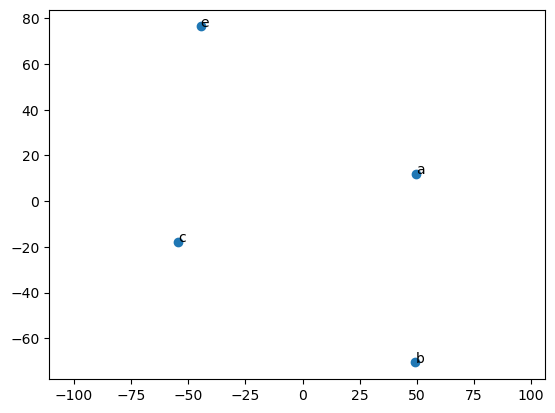

In [131]:
# coords for transmitters c, a, b, e
lon = [-1.450168, -1.448596,-1.448626, -1.449990] # x axis
lat = [53.368359, 53.368606, 53.367865,53.369204] # y axis
P = pyproj.Proj(proj='utm', zone=30, ellps='WGS84', preserve_units=True)
xxLon, yyLat = P(lon,lat)

def normaliseXY(coordsX, coordsY):
    Xavg = np.sum(coordsX)/len(coordsX)
    Yavg = np.sum(coordsY)/len(coordsY)
    for coord in range(len(coordsX)):
        coordsX[coord] = (coordsX[coord] - Xavg)
    for coord in range(len(coordsY)):
        coordsY[coord] = (coordsY[coord] - Yavg)
    return coordsX, coordsY, Xavg, Yavg

def reverseNormalizeXY(coordsX, coordsY, Xavg, Yavg):
    for coord in range(len(coordsX)):
        coordsX[coord] = coordsX[coord] + Xavg
    for coord in range(len(coordsY)):
        coordsY[coord] = coordsY[coord] + Yavg
    return coordsX, coordsY
    
xx,yy,Xaverage,Yaverage = normaliseXY(xxLon,yyLat)

plt.axis("equal")
plt.scatter(xx,yy)
plt.text(xx[0],yy[0],'c')
plt.text(xx[1],yy[1],'a')
plt.text(xx[2],yy[2],'b')
plt.text(xx[3],yy[3],'e')

In [133]:
testdata = Signals("../bluetooth_experiments/March 26 2025 Field Trial/complexpath8/complexpath8.log",['c','a','b','e'],filetype='log',angleOffset=0)

Standardising angles and times (shifting by 0.00 degrees)


In [135]:
testdata.summarise()
testdata.configureTransmitter('c',0,0,transmitterLat = yy[0], transmitterLon = xx[0])
testdata.configureTransmitter('a',-(167340+194210),0,transmitterLat = yy[1], transmitterLon = xx[1])
testdata.configureTransmitter('b',-(167340+194210+121110),0,transmitterLat = yy[2], transmitterLon = xx[2])
testdata.configureTransmitter('e',-167340,0,transmitterLat = yy[3], transmitterLon = xx[3])
#plt.plot(testdata.data[:,-1],testdata.data[:,0])

Transmitter       Number of records
        a                 6440
        b                 8629
        c                 9514
        e                 5895


In [137]:
burst, time = testdata.parseBursts(burstInterval=0)
angles = AnglesUsePeaks(5)

In [139]:
obs = []
obstimes = []

In [141]:
for i in range(len(burst)):
    prediction = angles.infer(burst[i]['rssis'], burst[i]['angles'])
    if not np.isnan(prediction):
        observation = np.array([burst[i]['transmitter_position'][0][0],burst[i]['transmitter_position'][0][1],np.cos(prediction),np.sin(prediction)])
        obstimes.append(time[i])
        obs.append(observation)

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [143]:
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / 100000
time_avg = np.mean(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_avg)

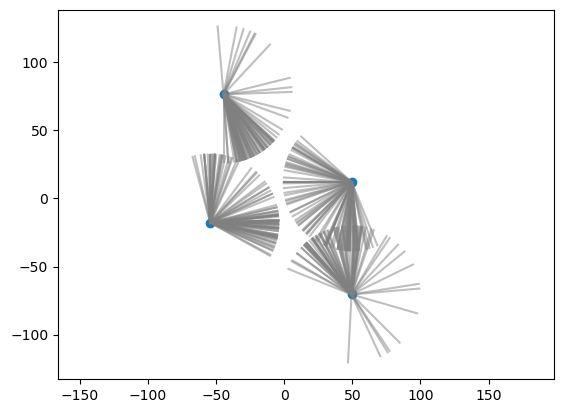

In [149]:
plt.axis('equal')
plt.scatter(xx,yy)
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[1], observation[1]+observation[3]*50],[observation[0],observation[0]+observation[2]*50],color='grey',alpha=0.5)
    #plt.text(observation[1]+observation[3]*45, observation[0]+observation[2]*45, time)

In [153]:
from BLEanalysis.pathinference import Path_VectorsToBee
k = EQIntegralKernel(10,50)
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,6,6)
path.jitter = 0.1
path.run(100,learning_rate=1, just_optimise_means = False)

Optimising mean...
iteration    0:   11002.2
iteration   50:    6560.2
Optimising mean and covariance...
iteration    0:    5769.7
iteration   50:       inf


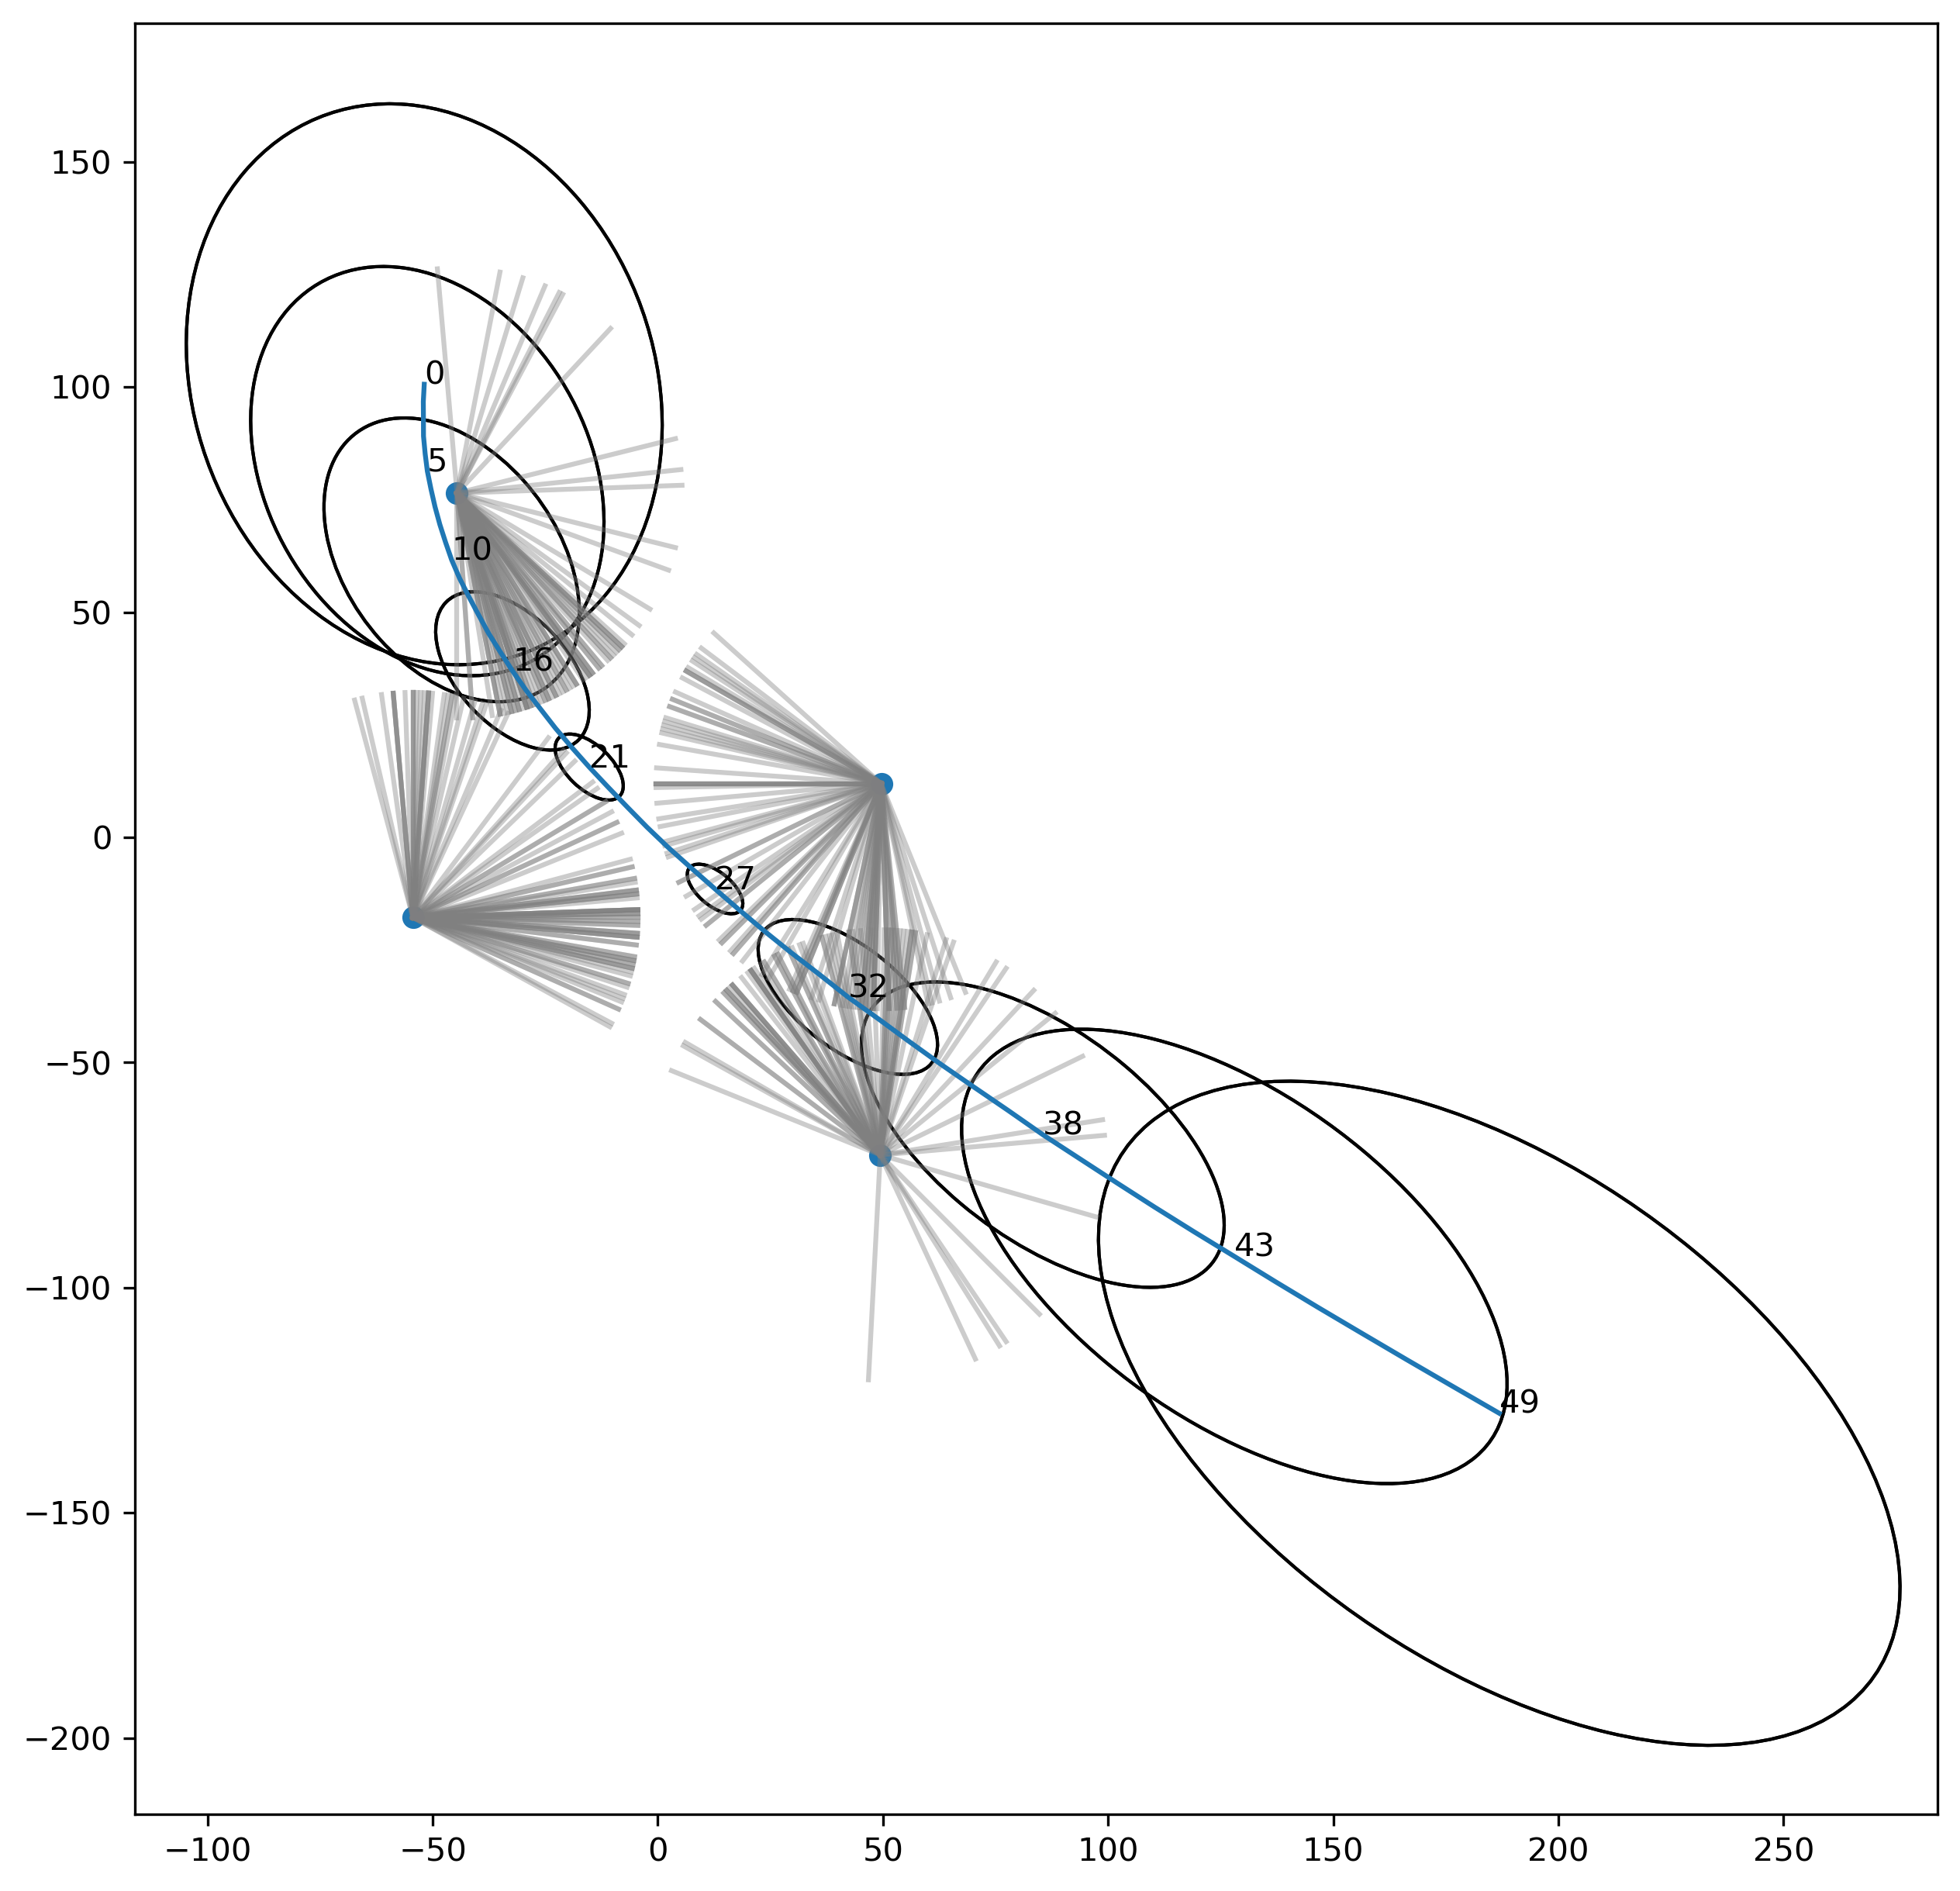

In [159]:
figure(figsize=(10, 10), dpi=300)
plt.axis("equal")
plt.scatter(xx,yy)
ax = plt.gca()

for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[1], observation[1]+observation[3]*50],[observation[0],observation[0]+observation[2]*50],color='grey',alpha=0.4)
n_test = 50
posterior_mean, posterior_cov = path.get_predictions(np.linspace(-2,2,n_test))
plt.plot(posterior_mean[:n_test],posterior_mean[n_test:],'-')
#ax = plt.gca()
for i in np.linspace(0,n_test-1,10).astype(int):
    el = confidence_ellipse(posterior_mean[i::n_test],posterior_cov[i::n_test,i::n_test],ax,n_std=4)
    ax.add_patch(el)
    plt.text(posterior_mean[i::n_test][0],posterior_mean[i::n_test][1],int(i))
#posterior_mean[0::n_test],posterior_cov[0::n_test,0::n_test]
plt.savefig('demo.png', transparent=True)